In [1]:
import gwsurrogate

/home/omkarnm1401/miniconda3/envs/ut_codex/lib/python3.11/site-packages/gwtools/const.py:52: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


In [2]:
import sys
# sys.path.append("/home/omkarnm1401/UT_Austin/BHPTutils")
# import bhpt_utils

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

In [5]:
from gwtools.gwtools import minimize_norm_error_multi_mode

In [6]:
# add the path to the script directory
sys.path.append("/home/omkarnm1401/UT_Austin/BHPTNRSurrogate/surrogates")
import BHPTNRSur1dq1e4 as bhptsur

/home/omkarnm1401/UT_Austin/BHPTNRSurrogate/surrogates/../data
**** Surrogate loaded: BHPTNRSur1dq1e4 ****


In [7]:
plot_dir = 'Notebook_plots/'

In [8]:
nrsur = gwsurrogate.LoadSurrogate('NRHybSur3dq8')

Loaded NRHybSur3dq8 model


In [9]:
# convience wrapper for calling the NRHybSur3dq8 model
def generate_nrsur(q_input, f_low=None, t_start=None):
    chiA = [0, 0, 0.0]
    chiB = [0, 0, 0.0]
    dt = 0.1        # step size, Units of M
    if f_low==None:
        f_low=5e-3
    if t_start==None:
        t_start=-5000.1
    # dyn stands for dynamics and is always None for this model
    t, h, dyn = nrsur(q_input, chiA, chiB, dt=dt, f_low=f_low) 
    # we only take the last 5000M long waveform to calibrate
    indx = np.where(t>=t_start)
    t = t[indx]
    for mode in h.keys():
        h[mode] = h[mode][indx]
    return t,h

In [10]:
tnr, h_NRHybSur3dq8 = generate_nrsur(q_input=5)

In [11]:
nr_modes = list(h_NRHybSur3dq8.keys())
for mode in nr_modes:
    if mode[1] <=0: # m<=0; remove the (2,0) and (3,0) modes from NRHybSur3dq8 (these are not included in the BHPTNRSur1dq1e4 model)
        h_NRHybSur3dq8.pop(mode)
        
tbhpt, hbhpt = bhptsur.generate_surrogate(q=5, modes=h_NRHybSur3dq8.keys(), calibrated=False, neg_modes=False)

**** warning **** : modes are NOT NR calibrated - waveforms only have 0PA contribution


In [12]:
q_input = 5
mass_norm = 1/(1+1/q_input)

In [13]:
h_NR_22 = h_NRHybSur3dq8[(2, 2)]

In [14]:
import gwtools

In [15]:
def mathcalE_error(h1, h2):
    """
    Compute time-domain waveform error.

    Calculates the normalized L2 error between two waveforms using the metric
    defined in Eq. 21 of https://arxiv.org/pdf/1701.00550.pdf

    Parameters:
    -----------
    h1 : array (complex)
        Reference waveform (used for normalization)
    h2 : array (complex)
        Comparison waveform (same length as h1)

    Returns:
    --------
    normed_errs : float
        Normalized error: (||h1||² + ||h2||² - 2*Re(<h1,h2>)) / (2*||h1||²)
        Value of 0 indicates perfect agreement, larger values indicate greater disagreement

    Notes:
    ------
    - Assumes h1 is the reference waveform and normalizes by its magnitude
    - Both waveforms should have the same time sampling
    - The metric is symmetric in the numerator but asymmetric due to normalization by ||h1||²
    """
    # Compute norms squared
    n1Sqr = np.sum(np.abs(h1)**2)
    n2Sqr = np.sum(np.abs(h2)**2)

    # Compute inner product
    dots = np.array([h1[i] * (h2[i].conjugate()) for i in range(len(h1))])
    sdot = np.real(np.sum(dots))

    # Normalize error by reference waveform magnitude
    normed_errs = ((n1Sqr + n2Sqr) - 2 * sdot) / (2 * n1Sqr)

    return normed_errs

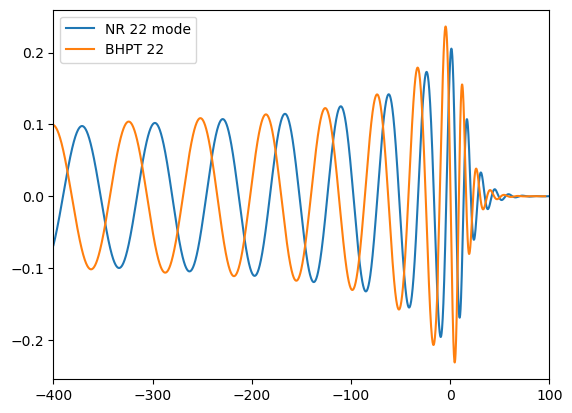

In [16]:
plt.plot(tnr, np.real(h_NR_22), label = 'NR 22 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(2,2)])  * mass_norm, label = 'BHPT 22')

plt.xlim(-400, 100)
plt.legend()

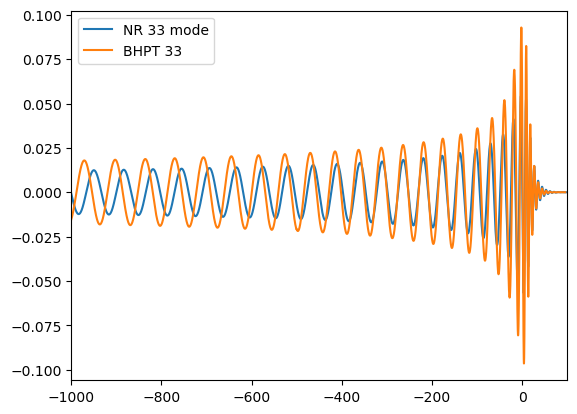

In [17]:
h_nr_33 = h_NRHybSur3dq8[(3, 3)]

plt.plot(tnr, np.real(h_nr_33), label = 'NR 33 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(3,3)])  * mass_norm, label = 'BHPT 33')

plt.xlim(-1000, 100)
plt.legend()

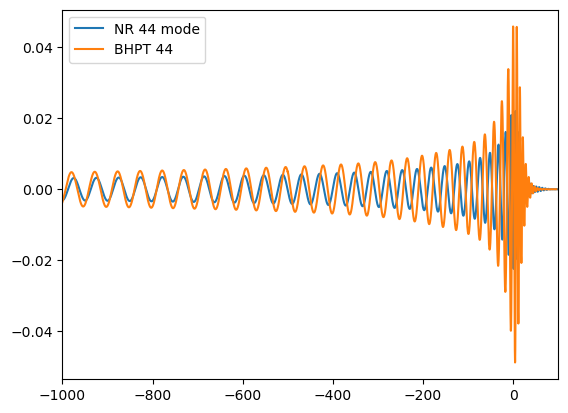

In [18]:
h_nr_44 = h_NRHybSur3dq8[(4, 4)]

plt.plot(tnr, np.real(h_nr_44), label = 'NR 44 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(4, 4)])  * mass_norm, label = 'BHPT 44')

plt.xlim(-1000, 100)
plt.legend()

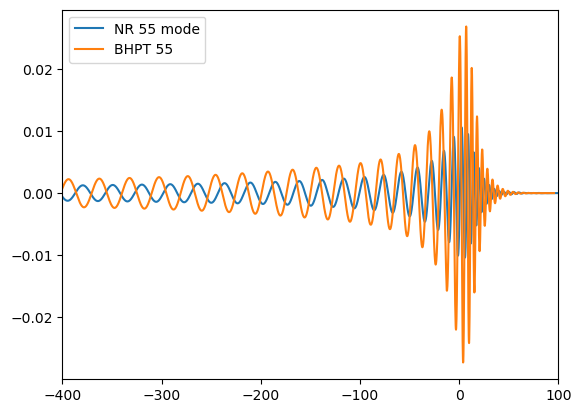

In [19]:
h_nr_55 = h_NRHybSur3dq8[(5, 5)]

plt.plot(tnr, np.real(h_nr_55), label = 'NR 55 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(5, 5)])  * mass_norm, label = 'BHPT 55')

plt.xlim(-400, 100)
plt.legend()

In [20]:
h_bhpt_interp = gwtools.interpolate_h(tbhpt * mass_norm, hbhpt[(2,2)], tnr)
mathcalE_error(h_NR_22, h_bhpt_interp)

>>> Warning: Requested samples are outside of interpolated domain.


np.float64(1.358614394200636)

In [21]:
# %load scaling_stricter.md
# Stricter q=5 (2,2) piecewise-linear scaling fit

#Using a two-segment linear fit for `alpha(s)` and `beta(s)` in raw BHPT source time `s`, I get:

#```python
t_start = -5000.0377442127
t_end = 100
t_cut = -172.554851971848  # optimized cutoff, constrained to be < -100M
s_min = -6211.57614051161
s_cut = -213.396540026457
s_max = 114.800000108869
#```

#For `s <= s_cut`:

#```python
def x_left(s):
    return (s - s_min) / (s_cut - s_min)
def x_right(s):
    return (s - s_cut) / (s_max - s_cut)

def alpha(s):
    return np.where(s<s_cut, 0.80542112672677 + (0.0103701734041557) * x_left(s), 0.858522261052373 + (-0.171022361144058) * x_right(s))

def tau(s):
    return np.where(s<s_cut, t_start + 0.804824665778662 * (s - s_min) + (1.06942324622101e-07) * (s - s_min) * (s - s_cut), t_cut + 0.830462295121895 * (s - s_cut) + (0.000135410789512007) * (s - s_cut) * (s - s_max))


def beta(s):
    return np.where(s<s_cut, 0.804824665778662 + (1.06942324622101e-07) * (2*s - s_min - s_cut), 0.830462295121895 + (0.000135410789512007) * (2*s - s_cut - s_max))




# Phase rotation:

# ```python
phi0 = 1.43742544198764  # radians, principal value
phi0_unwrapped = 510.375435323534
#```

# Applied as:

# ```python
tbhpt_extcal = tau(tbhpt)

hbhpt_extcal = {
    (2, 2): alpha(tbhpt) * hbhpt[(2,2)]
}
#```

# The fit uses raw `BHPTNRSur1dq1e4` with `calibrated=False`, `NRHybSur3dq8` with `dt=0.1`, `f_low=5e-3`, and the `mathcalE_error` definition in `NRBHP_ansatz.py` with NR as the reference waveform.

# Diagnostics:

# - q: `5`
# - mode: `(2, 2)`
# - optimized cutoff in NR time: `-172.554851971848`
# - corresponding BHPT source split: `-213.396540026457`
# - common NR support: `[-5000.0377442127, 99.9622557873008]`
# - beta endpoint values `(left_min, left_cut, right_cut, right_max)`: `(0.804183206508686, 0.805466125048639, 0.786020942507061, 0.874903647736728)`
# - optimizer downsampled `mathcalE`: `0.000270031466600323`
# - full-window `mathcalE`: `0.000269988438387273`
# - `t <= t_cut` local `mathcalE`: `8.54560576524473e-05`
# - `t > t_cut` local `mathcalE`: `0.0013492641787664`

#No extrapolated BHPT samples are used. The source interval is inside the raw BHPT support and endpoint BHPT values are obtained by interpolation within that support.

In [22]:
[errors_before_min, errors_after_min], [tc, phic], [common_times,h_bhpt_aligned,h_nr_aligned] = \
                            minimize_norm_error_multi_mode(tau(tbhpt),  hbhpt_extcal, tnr, h_NRHybSur3dq8, mode_list=None, ell_m_match=(2,2),\
                                    t_low_adj=0,t_up_adj=0,method='nelder-mead')

Performing a physical rotation by pi...


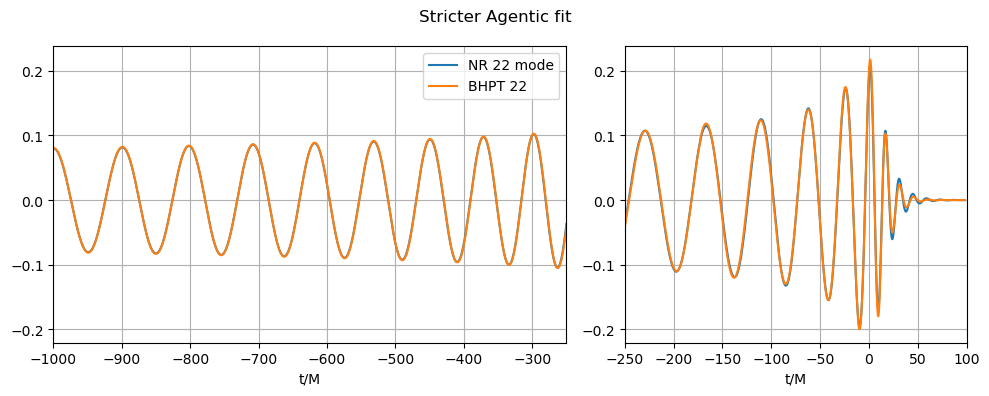

In [23]:
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [3, 2]}
)



ax1.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
ax1.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')

ax1.set_xlim(-1000, -250)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.legend()

ax2.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
ax2.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')
ax2.set_xlabel('t/M')

ax2.set_xlim(-250, 100)
ax2.grid(True)

plt.suptitle('Stricter Agentic fit')


plt.tight_layout()
plt.show()

In [24]:
mathcalE_error(h_bhpt_aligned[(2,2)], h_nr_aligned[(2,2)])

np.float64(0.00026654266754167085)

In [25]:
ab = {'beta': 0.803656511773389, 'alpha_l2m2': 0.804414592200569}


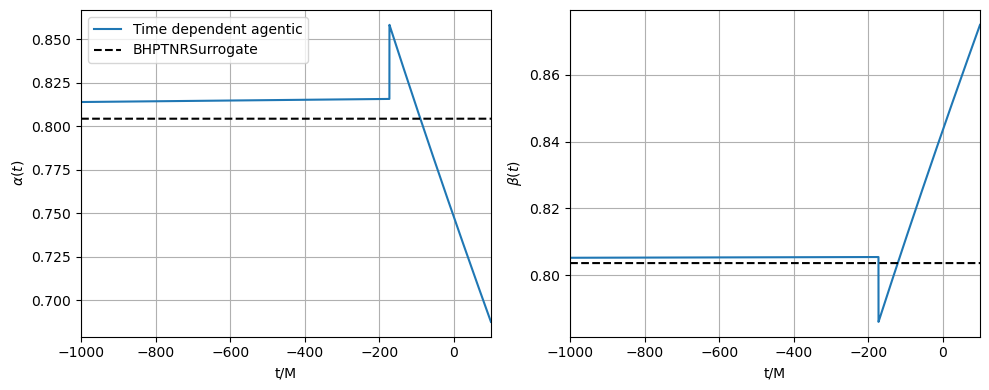

In [26]:
h_nr_22 = h_NRHybSur3dq8[(2, 2)]
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [2, 2]}
)



#ax1.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
ax1.plot(tbhpt_extcal, alpha(tbhpt), label = 'Time dependent agentic')
ax1.plot(tbhpt_extcal, np.ones(len(tbhpt_extcal)) * ab['alpha_l2m2'], label = 'BHPTNRSurrogate', linestyle = 'dashed', color = 'k')

ax1.set_xlim(-1000, 100)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.set_ylabel(r'$\alpha(t)$')
ax1.legend()

#ax2.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
ax2.plot(tbhpt_extcal, beta(tbhpt))
ax2.plot(tbhpt_extcal, np.ones(len(tbhpt_extcal)) * ab['beta'], linestyle = 'dashed', color = 'k')
ax2.set_xlabel('t/M')
ax2.set_ylabel(r'$\beta(t)$')

ax2.set_xlim(-1000, 100)
ax2.grid(True)

#plt.suptitle('Agentic fit')


plt.tight_layout()
#plt.savefig(plot_dir + 'Stricter_agentic_fit_params.pdf')
plt.show()

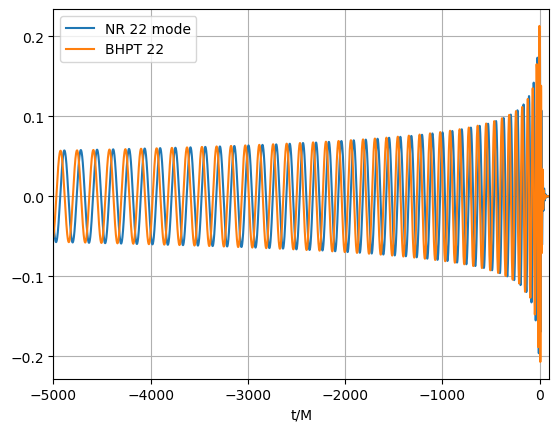

In [27]:
plt.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
plt.plot(tbhpt_extcal, np.real(hbhpt_extcal[(2, 2)]), label = 'BHPT 22')

plt.xlim(-5000, 100)
plt.grid(True)
plt.xlabel('t/M')
plt.legend()

In [28]:
mode_list = [
    mode for mode in hbhpt.keys()
    if mode[0] in [2, 3, 4, 5]
]

# Apply beta time rescaling.
# Use tbhpt / beta_fac(q) if your intended calibration is h_cal(t) = h_raw(beta * t)
hbhpt_extcal = {
    (2, 2): alpha(tbhpt) * np.exp(1j * phi0) * hbhpt[(2,2)]
}

# Apply alpha_l amplitude rescaling mode-by-mode
[errors_before_min, errors_after_min], [tc, phic], [common_times, h_bhpt_aligned, h_nr_aligned] = \
    minimize_norm_error_multi_mode(
        tbhpt_extcal,
        hbhpt_extcal,
        tnr,
        h_NRHybSur3dq8,
        mode_list=None,
        ell_m_match=(2, 2),
        t_low_adj=0,
        t_up_adj=0,
        method='nelder-mead'
    )

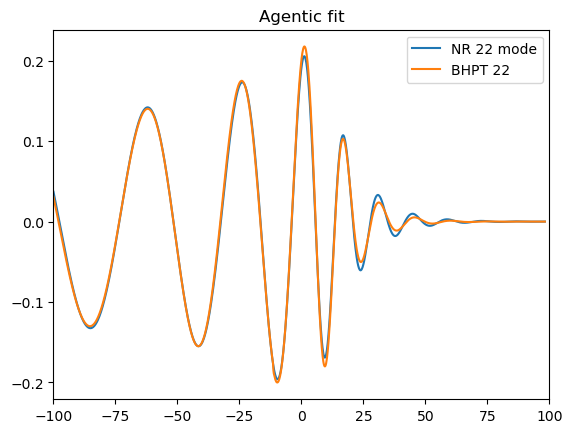

In [29]:
h_nr_22 = h_NRHybSur3dq8[(2, 2)]

plt.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
plt.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')

plt.xlim(-100, 100)
plt.title('Agentic fit')

plt.legend()
plt.show()